In [ ]:
# Core imports for the whole lab
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. PROBABILITY BY SIMULATION
# -----------------------------------------------------------

# P(A) = favourable outcomes / total outcomes.
# We can estimate it by simulating many trials.
rolls = np.random.randint(1, 7, size=100_000)   # 100k dice rolls

p_even = (rolls % 2 == 0).mean()       # P(even)
p_gt4  = (rolls > 4).mean()            # P(roll > 4)
print('P(even) ~', round(p_even, 3), ' (true 0.5)')
print('P(>4)   ~', round(p_gt4, 3),  ' (true 0.333)')

P(even) ~ 0.502  (true 0.5)
P(>4)   ~ 0.334  (true 0.333)


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. THE ADDITION RULE (disjoint events)
# -----------------------------------------------------------

# Rolling a 1 OR a 2 — these events can't both happen (disjoint)
p_1 = (rolls == 1).mean()
p_2 = (rolls == 2).mean()
p_1_or_2 = (np.isin(rolls, [1, 2])).mean()
print('P(1) + P(2) =', round(p_1 + p_2, 3))
print('P(1 or 2)   =', round(p_1_or_2, 3), ' -> they match')

P(1) + P(2) = 0.334
P(1 or 2)   = 0.334  -> they match


In [ ]:
flips = np.random.randint(0, 2, size=(100_000, 2))   # 100k pairs of flips
heads = flips.sum(axis=1)   # number of heads in each pair: 0, 1 or 2

# 1. P(both heads)  -> heads == 2
# YOUR CODE HERE
p_both_heads = (heads == 2).mean()
print('P(both heads) ~', round(p_both_heads, 3), ' (true 0.25)')

# 2. P(at least one head)  -> heads >= 1
# YOUR CODE HERE
p_at_least_one_head = (heads >= 1).mean()
print('P(at least one head) ~', round(p_at_least_one_head, 3), ' (true 0.75)')

# 3. Do P(0) + P(1) + P(2) sum to 1?
# YOUR CODE HERE
p_0_heads = (heads == 0).mean()
p_1_head = (heads == 1).mean()
p_2_heads = (heads == 2).mean()
total_prob = p_0_heads + p_1_head + p_2_heads
print('P(0) + P(1) + P(2) =', round(total_prob, 3), ' (should be 1.0)')

P(both heads) ~ 0.252  (true 0.25)
P(at least one head) ~ 0.749  (true 0.75)
P(0) + P(1) + P(2) = 1.0  (should be 1.0)


In [ ]:

# -----------------------------------------------------------
# 🔹 2A. CONDITIONAL PROBABILITY  P(A | B) = P(A and B) / P(B)
# -----------------------------------------------------------

rolls = np.random.randint(1, 7, size=100_000)

# P(roll is 6 | roll is even):  narrow the world to even rolls
even = rolls[rolls % 2 == 0]          # condition on 'even'
p_6_given_even = (even == 6).mean()
print('P(6 | even) ~', round(p_6_given_even, 3), ' (true 1/3)')

P(6 | even) ~ 0.332  (true 1/3)


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. TESTING FOR INDEPENDENCE
# -----------------------------------------------------------

# Two events are independent if P(A|B) == P(A).
# 'roll > 3' and 'roll is even' -> are they independent?
A = rolls > 3
B = rolls % 2 == 0
p_A        = A.mean()
p_A_given_B = A[B].mean()
print('P(A)      =', round(p_A, 3))
print('P(A | B)  =', round(p_A_given_B, 3))
print('Independent?', np.isclose(p_A, p_A_given_B, atol=0.02))

P(A)      = 0.498
P(A | B)  = 0.666
Independent? False


In [ ]:
rolls = np.random.randint(1, 7, size=100_000)

# 1. P(odd | roll < 4)  -> condition on rolls < 4, then check odd
# YOUR CODE HERE
rolls = rolls[rolls < 4] # Filter for rolls less than 4
p_odd  = (rolls % 2 == 1).mean()
print('P(odd | <4) ~', round(p_odd, 3), ' (true 0.5)')

# 2. P(roll < 4)
# YOUR CODE HERE
p = (rolls < 4).mean()
print('P(<4)       ~', round(p, 3), ' (true 0.5)')

# 3. Compare P(odd | <4) with P(odd) overall — independent?
# YOUR CODE HERE
p_odd_overall = (rolls % 2 == 1).mean()
print('P(odd) overall ~', round(p_odd_overall, 3), ' (true 0.5)')
print('Independent?', np.isclose(p_odd, p_odd_overall, atol=0.02))

P(odd | <4) ~ 0.667  (true 0.5)
P(<4)       ~ 1.0  (true 0.5)
P(odd) overall ~ 0.667  (true 0.5)
Independent? True


In [ ]:

# -----------------------------------------------------------
# 🔹 3A. THE MEDICAL-TEST PROBLEM (by formula)
# -----------------------------------------------------------

# Disease affects 1% of people; test is 99% accurate.
p_disease   = 0.01                       # prior  P(D)
p_pos_given_D  = 0.99                     # true positive rate  P(+|D)
p_pos_given_nD = 0.01                     # false positive rate P(+|not D)

# P(+) = P(+|D)P(D) + P(+|notD)P(notD)   (total probability)
p_pos = p_pos_given_D * p_disease + p_pos_given_nD * (1 - p_disease)

# Bayes: P(D | +)
p_D_given_pos = (p_pos_given_D * p_disease) / p_pos
print('P(sick | positive test) =', round(p_D_given_pos, 3))
print('-> only ~50%, because the disease is rare (base-rate effect)')

P(sick | positive test) = 0.5
-> only ~50%, because the disease is rare (base-rate effect)


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. THE SAME ANSWER BY SIMULATION (sanity check)
# -----------------------------------------------------------

N = 1_000_000
has_disease = np.random.rand(N) < p_disease
# test result depends on disease status
tests_pos = np.where(has_disease,
                     np.random.rand(N) < p_pos_given_D,    # sick -> 99% positive
                     np.random.rand(N) < p_pos_given_nD)   # healthy -> 1% positive

among_positive = has_disease[tests_pos]      # of those who tested positive...
print('Simulated P(sick | positive) =', round(among_positive.mean(), 3))

Simulated P(sick | positive) = 0.496


In [ ]:
# 1. priors / likelihoods
p_spam = 0.20
p_free_given_spam = 0.60
p_free_given_ham  = 0.05

# 2. P('free') via total probability
# YOUR CODE HERE
p_ham = 1 - p_spam
p_free = (p_free_given_spam * p_spam) + (p_free_given_ham * p_ham)
print(f"P('free') = {p_free:.3f}")

# 3. Bayes: P(spam | 'free')
# YOUR CODE HERE
p_spam_given_free = (p_free_given_spam * p_spam) / p_free
print(f"P(spam | 'free') = {p_spam_given_free:.3f}")

P('free') = 0.160
P(spam | 'free') = 0.750


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. BERNOULLI & POISSON (discrete)
# -----------------------------------------------------------

# Bernoulli: a single yes/no trial with probability p
bern = stats.bernoulli(p=0.3).rvs(size=10_000)
print('Bernoulli(0.3) mean ~', round(bern.mean(), 3), '(true 0.3)')

# Poisson: count of events per interval, rate lambda
pois = stats.poisson(mu=4).rvs(size=10_000)
print('Poisson(4) mean ~', round(pois.mean(), 3), '(true 4)')

Bernoulli(0.3) mean ~ 0.295 (true 0.3)
Poisson(4) mean ~ 4.012 (true 4)


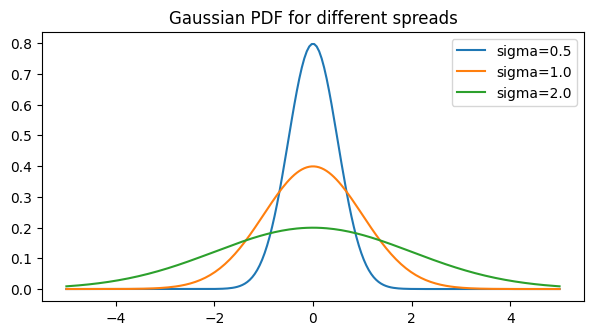

In [ ]:

# -----------------------------------------------------------
# 🔹 4B. THE GAUSSIAN (normal) — plot the bell curve
# -----------------------------------------------------------

x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [0.5, 1.0, 2.0]:
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for different spreads'); ax.legend(); plt.show()

Poisson(2) mean ~ 2.024 (true 2)


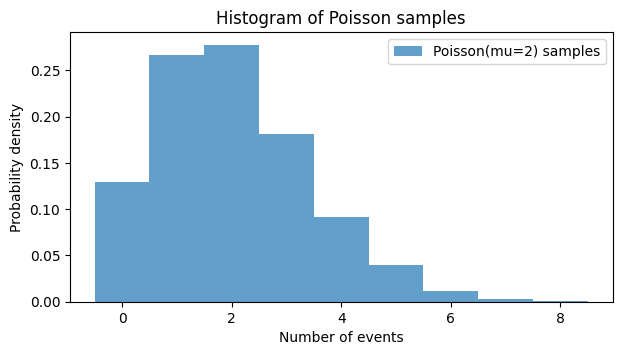

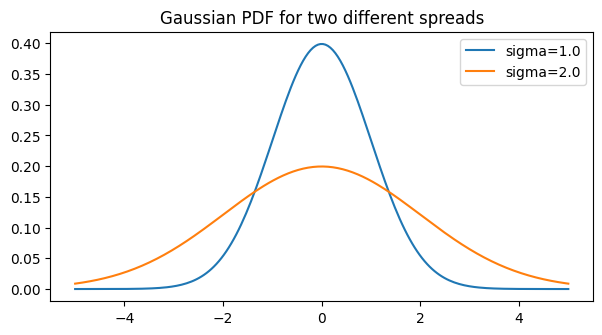

In [ ]:
# 1. Poisson(mu=2) samples + mean
pois = stats.poisson(mu=2).rvs(size=10_000)
print('Poisson(2) mean ~', round(pois.mean(), 3), '(true 2)')

# 2. histogram of the samples  (plt.hist(...))
plt.figure(figsize=(7, 3.5))
plt.hist(pois, bins=np.arange(0, pois.max() + 2) - 0.5, density=True, alpha=0.7, label='Poisson(mu=2) samples')
plt.title('Histogram of Poisson samples')
plt.xlabel('Number of events')
plt.ylabel('Probability density')
plt.legend()
plt.show()

# 3. Gaussian PDF for two sigmas on one plot
x = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(7, 3.5))
for sigma in [1.0, 2.0]: # Using 1.0 and 2.0 as examples
    ax.plot(x, stats.norm(0, sigma).pdf(x), label=f'sigma={sigma}')
ax.set_title('Gaussian PDF for two different spreads');
ax.legend();
plt.show()

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. ENTROPY — how uncertain is a distribution?
# -----------------------------------------------------------

from scipy.stats import entropy

fair   = [0.5, 0.5]      # a fair coin: maximum uncertainty
biased = [0.9, 0.1]      # a biased coin: more predictable
certain= [1.0, 0.0]      # no uncertainty at all

# base=2 gives entropy in BITS
print('Entropy fair coin   :', round(entropy(fair, base=2), 3), 'bits')
print('Entropy biased coin :', round(entropy(biased, base=2), 3), 'bits')
print('Entropy certain     :', round(entropy(certain, base=2), 3), 'bits')

Entropy fair coin   : 1.0 bits
Entropy biased coin : 0.469 bits
Entropy certain     : 0.0 bits


In [ ]:

# -----------------------------------------------------------
# 🔹 5B. KL DIVERGENCE — how far is Q from P?
# -----------------------------------------------------------

P = np.array([0.5, 0.5])
Q = np.array([0.9, 0.1])

# scipy's entropy(P, Q) computes the KL divergence D(P || Q)
print('D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')
print('D(P || P) =', round(entropy(P, P, base=2), 3), '-> zero (identical)')
print('Note: D(P||Q) != D(Q||P)  ->', round(entropy(Q, P, base=2), 3), '(not symmetric)')

D(P || Q) = 0.737 bits
D(P || P) = 0.0 -> zero (identical)
Note: D(P||Q) != D(Q||P)  -> 0.531 (not symmetric)


In [ ]:
# -----------------------------------------------------------
# 🔹 5C. MUTUAL INFORMATION — which feature is most informative?
# -----------------------------------------------------------

from sklearn.feature_selection import mutual_info_classif
from sklearn.datasets import load_iris

iris = load_iris()
mi = mutual_info_classif(iris.data, iris.target, random_state=0)
for name, score in sorted(zip(iris.feature_names, mi), key=lambda t: -t[1]):
    print(f'{score:.3f}  {name}')
print('-> higher MI = the feature tells us more about the class')

0.990  petal length (cm)
0.975  petal width (cm)
0.474  sepal length (cm)
0.286  sepal width (cm)
-> higher MI = the feature tells us more about the class


In [ ]:
# 1. Entropy of a fair 4-sided and 6-sided die (use base=2)
# hint: a fair n-sided die is [1/n]*n
# YOUR CODE HERE
prob_4_sided = [1/4, 1/4, 1/4, 1/4]
prob_6_sided = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]
print('Entropy fair 4-sided die:', round(entropy(prob_4_sided, base=2), 3), 'bits')
print('Entropy fair 6-sided die:', round(entropy(prob_6_sided, base=2), 3), 'bits')

# 2. KL divergence D(P || Q)
P = np.array([0.7, 0.3]); Q = np.array([0.5, 0.5])
# YOUR CODE HERE
print('KL divergence D(P || Q) =', round(entropy(P, Q, base=2), 3), 'bits')

# 3. Most / least informative iris feature (from 5C)
# Most informative: ...   Least informative: ...
print('Most informative: petal length (cm)')
print('Least informative: sepal width (cm)')

Entropy fair 4-sided die: 2.0 bits
Entropy fair 6-sided die: 2.585 bits
KL divergence D(P || Q) = 0.119 bits
Most informative: petal length (cm)
Least informative: sepal width (cm)


Data CLeaning

In [ ]:
# Core imports for the whole lab
import pandas as pd
import json

print('Setup complete. pandas', pd.__version__)


Setup complete. pandas 2.2.2


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. THE EIGHT STAGES, IN ORDER
# -----------------------------------------------------------

lifecycle = [
    'Define',    # frame the business problem
    'Collect',   # gather & ingest data
    'Prepare',   # clean & transform
    'Explore',   # EDA & visualise
    'Model',     # train algorithms
    'Evaluate',  # test & validate
    'Deploy',    # serve predictions
    'Monitor',   # watch & maintain  (then loop back!)
]
for i, stage in enumerate(lifecycle, start=1):
    print(f'{i}. {stage}')


1. Define
2. Collect
3. Prepare
4. Explore
5. Model
6. Evaluate
7. Deploy
8. Monitor


In [ ]:
# -----------------------------------------------------------
# 🔹 1B. WHAT HAPPENS AT EACH STAGE
# -----------------------------------------------------------

what_happens = {
    'Define':   'turn a business question into an ML problem',
    'Collect':  'pull data from files, databases, APIs',
    'Prepare':  'clean missing values, fix types, engineer features',
    'Explore':  'summarise & visualise to find patterns',
    'Model':    'train and tune algorithms',
    'Evaluate': 'measure performance on unseen data',
    'Deploy':   'put the model into production',
    'Monitor':  'track performance and retrain as needed',
}
for stage, desc in what_happens.items():
    print(f'{stage:9s} -> {desc}')

Define    -> turn a business question into an ML problem
Collect   -> pull data from files, databases, APIs
Prepare   -> clean missing values, fix types, engineer features
Explore   -> summarise & visualise to find patterns
Model     -> train and tune algorithms
Evaluate  -> measure performance on unseen data
Deploy    -> put the model into production
Monitor   -> track performance and retrain as needed


In [ ]:
shuffled = ['Model', 'Define', 'Deploy', 'Collect', 'Monitor',
            'Prepare', 'Evaluate', 'Explore']

# 1 & 2. sort 'shuffled' by position in 'lifecycle'
#   hint: sorted(shuffled, key=lifecycle.index)
# YOUR CODE HERE
sorted_lifecycle = sorted(shuffled, key=lifecycle.index)
print(f'Sorted lifecycle: {sorted_lifecycle}')
# 3. confirm it matches the reference order
# YOUR CODE HERE
match = (sorted_lifecycle == lifecycle)
print(f'Does the sorted list match the reference order? {match}')


Sorted lifecycle: ['Define', 'Collect', 'Prepare', 'Explore', 'Model', 'Evaluate', 'Deploy', 'Monitor']
Does the sorted list match the reference order? True


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. THE SIX CRISP-DM PHASES
# -----------------------------------------------------------

crisp_dm = [
    'Business Understanding',
    'Data Understanding',
    'Data Preparation',
    'Modeling',
    'Evaluation',
    'Deployment',
]
for i, phase in enumerate(crisp_dm, start=1):
    print(f'{i}. {phase}')

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Deployment


In [ ]:
# -----------------------------------------------------------
# 🔹 2B. MAP LIFECYCLE STAGES -> CRISP-DM PHASES
# -----------------------------------------------------------

# Several lifecycle stages can fall under one CRISP-DM phase.
mapping = {
    'Define':   'Business Understanding',
    'Collect':  'Data Understanding',
    'Explore':  'Data Understanding',
    'Prepare':  'Data Preparation',
    'Model':    'Modeling',
    'Evaluate': 'Evaluation',
    'Deploy':   'Deployment',
    'Monitor':  'Deployment',
}
for stage, phase in mapping.items():
    print(f'{stage:9s} -> {phase}')

Define    -> Business Understanding
Collect   -> Data Understanding
Explore   -> Data Understanding
Prepare   -> Data Preparation
Model     -> Modeling
Evaluate  -> Evaluation
Deploy    -> Deployment
Monitor   -> Deployment


In [ ]:
# 1. invert the mapping: group stages by phase
#   hint: build a dict, append each stage to mapping[stage]'s list
grouped = {}
# YOUR CODE HERE
for stage, phase in mapping.items():
    if phase not in grouped:
        grouped[phase] = []
    grouped[phase].append(stage)
# 2. print phase -> stages
# YOUR CODE HERE
print('Stages grouped by CRISP-DM phase:')
for phase, stages in grouped.items():
    print(f'{phase:20s} -> {', '.join(stages)}')
# 3. which phase has the most stages?  (max by length)
# YOUR CODE HERE
most_stages_phase = max(grouped, key=lambda phase: len(grouped[phase]))
print(f'\nPhase with the most stages: {most_stages_phase} ({len(grouped[most_stages_phase])} stages)')

Stages grouped by CRISP-DM phase:
Business Understanding -> Define
Data Understanding   -> Collect, Explore
Data Preparation     -> Prepare
Modeling             -> Model
Evaluation           -> Evaluate
Deployment           -> Deploy, Monitor

Phase with the most stages: Data Understanding (2 stages)


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. STRUCTURED / SEMI-STRUCTURED / UNSTRUCTURED
# -----------------------------------------------------------

examples = {
    'a SQL users table':        'structured',
    'a CSV of sales':           'structured',
    'a JSON API response':      'semi-structured',
    'an XML config file':       'semi-structured',
    'a folder of photos':       'unstructured',
    'customer review text':     'unstructured',
}
for item, kind in examples.items():
    print(f'{kind:16s} <- {item}')


structured       <- a SQL users table
structured       <- a CSV of sales
semi-structured  <- a JSON API response
semi-structured  <- an XML config file
unstructured     <- a folder of photos
unstructured     <- customer review text


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. A SIMPLE CLASSIFIER
# -----------------------------------------------------------

def classify(fmt):
    fmt = fmt.lower()
    if fmt in ('csv', 'sql', 'parquet', 'excel', 'xlsx'):
        return 'structured'
    if fmt in ('json', 'xml', 'yaml', 'log'):
        return 'semi-structured'
    return 'unstructured'   # text, image, audio, video, ...

for fmt in ['csv', 'json', 'jpg', 'sql', 'xml', 'mp3']:
    print(f'{fmt:6s} -> {classify(fmt)}')

csv    -> structured
json   -> semi-structured
jpg    -> unstructured
sql    -> structured
xml    -> semi-structured
mp3    -> unstructured


In [ ]:
import collections

to_label = ['parquet', 'yaml', 'png', 'csv', 'wav', 'json', 'txt']

# 1. classify each one
# YOUR CODE HERE
def classify(fmt):
    fmt = fmt.lower()
    if fmt in ('csv', 'sql', 'parquet', 'excel', 'xlsx'):
        return 'structured'
    if fmt in ('json', 'xml', 'yaml', 'log'):
        return 'semi-structured'
    return 'unstructured'   # text, image, audio, video, ...

classified_data = [classify(fmt) for fmt in to_label]
for fmt, category in zip(to_label, classified_data):
    print(f'{fmt:8s} -> {category}')

# 2. count per category  (hint: collections.Counter)
# YOUR CODE HERE
category_counts = collections.Counter(classified_data)
print(f'\nCategory counts: {category_counts}')

# 3. An ML task that uses unstructured data: ...   (write your answer)
print('\nAn ML task that uses unstructured data: Image classification (e.g., classifying images of cats vs. dogs)')

parquet  -> structured
yaml     -> semi-structured
png      -> unstructured
csv      -> structured
wav      -> unstructured
json     -> semi-structured
txt      -> unstructured

Category counts: Counter({'unstructured': 3, 'structured': 2, 'semi-structured': 2})

An ML task that uses unstructured data: Image classification (e.g., classifying images of cats vs. dogs)


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. WRITE A CSV, THEN READ IT BACK
# -----------------------------------------------------------

# (in real life the CSV already exists; here we create one so the lab is self-contained)
sample = pd.DataFrame({
    'name':   ['Ana', 'Bo', 'Cy', 'Di'],
    'age':    [30, 25, 41, 38],
    'city':   ['Pune', 'Delhi', 'Pune', 'Hyderabad'],
    'spend':  [120.5, 80.0, 200.2, 150.0],
})
sample.to_csv('people.csv', index=False)   # write

df = pd.read_csv('people.csv')             # read back
df.head()

,name,age,city,spend
0,Ana,30,Pune,120.5
1,Bo,25,Delhi,80.0
2,Cy,41,Pune,200.2
3,Di,38,Hyderabad,150.0


In [ ]:
# -----------------------------------------------------------
# 🔹 4B. ALWAYS INSPECT A NEW DATAFRAME
# -----------------------------------------------------------

print('shape :', df.shape)        # (rows, columns)
print()
print('dtypes:')
print(df.dtypes)                  # the type of each column
print()
df.describe(include='all')        # quick summary

shape : (4, 4)

dtypes:
name      object
age        int64
city      object
spend    float64
dtype: object



,name,age,city,spend
count,4,4.000000,4,4.000000
unique,4,NaN,3,NaN
top,Ana,NaN,Pune,NaN
freq,1,NaN,2,NaN
mean,NaN,33.500000,NaN,137.675000
std,NaN,7.325754,NaN,50.605229
min,NaN,25.000000,NaN,80.000000
25%,NaN,28.750000,NaN,110.375000
50%,NaN,34.000000,NaN,135.250000
75%,NaN,38.750000,NaN,162.550000


In [ ]:
# -----------------------------------------------------------
# 🔹 4C. READING JSON (semi-structured -> table)
# -----------------------------------------------------------

# JSON often comes nested; json_normalize flattens it into columns
records = [
    {'id': 1, 'user': {'name': 'Ana', 'city': 'Pune'}, 'spend': 120.5},
    {'id': 2, 'user': {'name': 'Bo',  'city': 'Delhi'}, 'spend': 80.0},
]
json_df = pd.json_normalize(records)   # note the 'user.name', 'user.city' columns
json_df


,id,spend,user.name,user.city
0,1,120.5,Ana,Pune
1,2,80.0,Bo,Delhi


In [ ]:
# 1. build the DataFrame
# YOUR CODE HERE
products_df = pd.DataFrame({
    'product_id': [101, 102, 103, 104],
    'product_name': ['Laptop', 'Mouse', 'Keyboard', 'Monitor'],
    'price': [1200.0, 25.0, 75.0, 300.0],
    'category': ['Electronics', 'Electronics', 'Electronics', 'Electronics']
})

# 2. write to 'products.csv' then read it back
# YOUR CODE HERE
products_df.to_csv('products.csv', index=False)
read_products_df = pd.read_csv('products.csv')
display(read_products_df.head())

# 3. inspect shape & dtypes
# YOUR CODE HERE
print('\nShape of products_df:', read_products_df.shape)
print('\nData types of products_df:')
print(read_products_df.dtypes)

,product_id,product_name,price,category
0,101,Laptop,1200.0,Electronics
1,102,Mouse,25.0,Electronics
2,103,Keyboard,75.0,Electronics
3,104,Monitor,300.0,Electronics



Shape of products_df: (4, 4)

Data types of products_df:
product_id        int64
product_name     object
price           float64
category         object
dtype: object


In [ ]:
# -----------------------------------------------------------
# 🔹 5A. FETCH JSON FROM A PUBLIC API
# -----------------------------------------------------------
import requests

API_URL = 'https://jsonplaceholder.typicode.com/users'   # a free demo API

# Pattern: GET the URL -> parse JSON -> build a DataFrame.
# We wrap it in try/except so the lab still runs if you're offline;
# in that case we fall back to a small inline sample.
try:
    resp = requests.get(API_URL, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    print('Fetched', len(data), 'records from the live API.')
except Exception as e:
    print('Network unavailable (', type(e).__name__, ') - using inline sample.')
    data = [
        {'id': 1, 'name': 'Leanne Graham',  'username': 'Bret',     'email': 'sincere@april.biz'},
        {'id': 2, 'name': 'Ervin Howell',   'username': 'Antonette','email': 'shanna@melissa.tv'},
        {'id': 3, 'name': 'Clementine Bauch','username': 'Samantha','email': 'nathan@yesenia.net'},
    ]

api_df = pd.json_normalize(data)
api_df.head()

Fetched 10 records from the live API.


,id,name,username,email,phone,website,address.street,address.suite,address.city,address.zipcode,address.geo.lat,address.geo.lng,company.name,company.catchPhrase,company.bs
0,1,Leanne Graham,Bret,Sincere@april.biz,1-770-736-8031 x56442,hildegard.org,Kulas Light,Apt. 556,Gwenborough,92998-3874,-37.3159,81.1496,Romaguera-Crona,Multi-layered client-server neural-net,harness real-time e-markets
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,010-692-6593 x09125,anastasia.net,Victor Plains,Suite 879,Wisokyburgh,90566-7771,-43.9509,-34.4618,Deckow-Crist,Proactive didactic contingency,synergize scalable supply-chains
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,1-463-123-4447,ramiro.info,Douglas Extension,Suite 847,McKenziehaven,59590-4157,-68.6102,-47.0653,Romaguera-Jacobson,Face to face bifurcated interface,e-enable strategic applications
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,493-170-9623 x156,kale.biz,Hoeger Mall,Apt. 692,South Elvis,53919-4257,29.4572,-164.2990,Robel-Corkery,Multi-tiered zero tolerance productivity,transition cutting-edge web services
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,(254)954-1289,demarco.info,Skiles Walks,Suite 351,Roscoeview,33263,-31.8129,62.5342,Keebler LLC,User-centric fault-tolerant solution,revolutionize end-to-end systems


In [ ]:
# -----------------------------------------------------------
# 🔹 5B. INSPECT & SELECT FROM THE API DATA
# -----------------------------------------------------------

print('shape:', api_df.shape)
# keep just a few useful columns (these exist in both live & sample data)
cols = [c for c in ['id', 'name', 'username', 'email'] if c in api_df.columns]
api_df[cols].head()

shape: (10, 15)


,id,name,username,email
0,1,Leanne Graham,Bret,Sincere@april.biz
1,2,Ervin Howell,Antonette,Shanna@melissa.tv
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca


In [ ]:
POSTS_URL = 'https://jsonplaceholder.typicode.com/posts'

# 1. fetch (try/except with a small inline fallback)
try:
    resp = requests.get(POSTS_URL, timeout=10)
    resp.raise_for_status()
    data = resp.json()
    print('Fetched', len(data), 'records from the live API.')
except Exception as e:
    print('Network unavailable (', type(e).__name__, ') - using inline sample.')
    data = [
        {'userId': 1, 'id': 1, 'title': 'sunt aut facere', 'body': 'quia et suscipit\nsuscipit recusandae'},
        {'userId': 1, 'id': 2, 'title': 'qui est esse', 'body': 'est rerum tempore vitae\nsequi sint nihil'},
        {'userId': 1, 'id': 3, 'title': 'ea molestias quasi', 'body': 'et iusto sed quo iure\nvoluptatem occaecati'},
    ]

# 2. build the DataFrame
posts_df = pd.json_normalize(data)

# 3. shape + first 3 rows
print('shape:', posts_df.shape)
display(posts_df.head(3))

In [ ]:
# -----------------------------------------------------------
# 🔹 4A. WRITE A CSV, THEN READ IT BACK
# -----------------------------------------------------------

# (in real life the CSV already exists; here we create one so the lab is self-contained)
sample = pd.DataFrame({
    'name':   ['Ana', 'Bo', 'Cy', 'Di'],
    'age':    [30, 25, 41, 38],
    'city':   ['Pune', 'Delhi', 'Pune', 'Hyderabad'],
    'spend':  [120.5, 80.0, 200.2, 150.0],
})
sample.to_csv('people.csv', index=False)   # write

df = pd.read_csv('people.csv')             # read back
df.head()

,name,age,city,spend
0,Ana,30,Pune,120.5
1,Bo,25,Delhi,80.0
2,Cy,41,Pune,200.2
3,Di,38,Hyderabad,150.0


Pandas

kaggle

In [ ]:
!pip install kaggle kagglehub

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lnikitha","key":"525c9aef141b7c62d9f43ab097f8b22a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d laveshjadon/news-nlp-features-dataset

Dataset URL: https://www.kaggle.com/datasets/laveshjadon/news-nlp-features-dataset
License(s): MIT
100% 734k/734k [00:00<00:00, 73.7MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile("news-nlp-features-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("News")

In [ ]:
import pandas as pd

df = pd.read_csv("/content/news-nlp-features-dataset.zip")
df.head()

,date,stock,final_sentiment,news_count,sentiment_std,sentiment_x_news,sentiment_range,sentiment_lag1,sentiment_lag3,sentiment_roll3,sentiment_roll7,sentiment_momentum,net_sentiment_ratio
0,2017-02-15,ADANIPORTS,-0.082270,1,NaN,-0.082270,0.0,NaN,NaN,NaN,NaN,NaN,-0.999999
1,2017-03-07,ADANIPORTS,-0.476664,1,NaN,-0.476664,0.0,-0.082270,NaN,NaN,NaN,NaN,-0.999999
2,2017-05-09,ADANIPORTS,1.128783,1,NaN,1.128783,0.0,-0.476664,NaN,NaN,NaN,NaN,0.999999
3,2017-06-15,ADANIPORTS,0.879525,1,NaN,0.879525,0.0,1.128783,-0.082270,0.189950,NaN,1.211053,0.999999
4,2017-06-26,ADANIPORTS,1.654368,1,NaN,1.654368,0.0,0.879525,-0.476664,0.510548,NaN,1.356189,0.999999


In [ ]:
import kagglehub

stock = kagglehub.dataset_download("laveshjadon/news-nlp-features-dataset")

print("Dataset downloaded to:", stock)

Using Colab cache for faster access to the 'news-nlp-features-dataset' dataset.
Dataset downloaded to: /kaggle/input/news-nlp-features-dataset


In [ ]:
df = pd.read_csv(stock + "/dataset/train_and_test2.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/news-nlp-features-dataset/dataset/train_and_test2.csv'

In [ ]:
import requests
import pandas as pd

url = "https://api.exchangerate-api.com/v4/latest/USD"

response = requests.get(url)
data = response.json()

rates = data["rates"]

df = pd.DataFrame(list(rates.items()), columns=["Currency","Rate"])
df.head()


,Currency,Rate
0,USD,1.00
1,AED,3.67
2,AFN,63.57
3,ALL,82.40
4,AMD,368.41


In [ ]:

import sqlite3
import pandas as pd

conn = sqlite3.connect("bank.db")

data = {
    "Customer_ID":[1,2,3,4],
    "Loan_Amount":[200000,150000,300000,180000],
    "Credit_Score":[720,680,650,700]
}

df = pd.DataFrame(data)

df.to_sql("customers", conn, if_exists="replace", index=False)


4

In [ ]:
query = "SELECT * FROM customers"

df = pd.read_sql(query, conn)
df.head()

,Customer_ID,Loan_Amount,Credit_Score
0,1,200000,720
1,2,150000,680
2,3,300000,650
3,4,180000,700


In [ ]:
print("--- Intermediate Pandas Exercise ---")
print("Complete each task by writing the requested Pandas code.")
print("------------------------------------")

# Task 1: Basic Pandas Functions and Converting Arrays to DataFrames
print("\n--- Task 1: Basic Pandas Functions and Converting Arrays to DataFrames ---")
# 1.1 Create a Pandas Series named 's1_1' from a list of numbers [10, 20, 30, 40, 50].
# 1.2 Create a 3x4 NumPy array named 'np_array1_2' with random integers between 1 and 100.
# 1.3 Convert 'np_array1_2' into a Pandas DataFrame named 'df1_3' with columns 'A', 'B', 'C', 'D'.

# Your code for Task 1 here:
s1_1 = pd.Series([10, 20, 30, 40, 50])
print(f's1_1:\n{s1_1}')

np_array1_2 = np.random.randint(1, 101, size=(3, 4))
print(f'\nnp_array1_2:\n{np_array1_2}')

df1_3 = pd.DataFrame(np_array1_2, columns=['A', 'B', 'C', 'D'])
print(f'\ndf1_3:\n{df1_3}')

# Task 2: Synthetic Data Generation for Practice
print("\n--- Task 2: Synthetic Data Generation for Practice ---")
# Create a DataFrame named 'df_sales' with 100 rows and the following columns:
# - 'Date': A range of dates from '2023-01-01' to '2023-04-09' (inclusive).
# - 'Region': Randomly chosen from ['East', 'West', 'North', 'South'].
# - 'Product': Randomly chosen from ['Laptop', 'Mouse', 'Keyboard', 'Monitor'].
# - 'Sales': Random integers between 100 and 1000.
# - 'Quantity': Random integers between 1 and 10.
# - Introduce 5 random NaN values in the 'Sales' column and 3 random NaN values in the 'Quantity' column.

# Your code for Task 2 here:
dates = pd.date_range(start='2023-01-01', end='2023-04-09')
num_rows = len(dates)

df_sales = pd.DataFrame({
    'Date': dates,
    'Region': np.random.choice(['East', 'West', 'North', 'South'], size=num_rows),
    'Product': np.random.choice(['Laptop', 'Mouse', 'Keyboard', 'Monitor'], size=num_rows),
    'Sales': np.random.randint(100, 1001, size=num_rows),
    'Quantity': np.random.randint(1, 11, size=num_rows)
})

# Introduce NaN values
np.random.seed(42)
sales_nan_indices = np.random.choice(df_sales.index, 5, replace=False)
quantity_nan_indices = np.random.choice(df_sales.index, 3, replace=False)

df_sales.loc[sales_nan_indices, 'Sales'] = np.nan
df_sales.loc[quantity_nan_indices, 'Quantity'] = np.nan

print(f'\ndf_sales (with NaNs):\n{df_sales.head()}')
print(f'\nNaN counts:\n{df_sales.isnull().sum()}')


# Task 3: Indexing and Slicing in DataFrames
print("\n--- Task 3: Indexing and Slicing in DataFrames ---")
# Use 'df_sales' from Task 2.
# 3.1 Select only the 'Region' and 'Sales' columns. Store it in 'df3_1'.
# 3.2 Select rows where 'Product' is 'Laptop'. Store it in 'df3_2'.
# 3.3 Select rows where 'Region' is 'East' AND 'Sales' are greater than 500. Store it in 'df3_3'.
# 3.4 Select the 'Sales' value for the first entry where 'Product' is 'Monitor' (use .loc and .iloc). Store it in 'val3_4'.

# Your code for Task 3 here:
df3_1 = df_sales[['Region', 'Sales']]
print(f'\n3.1 Selected columns (Region, Sales):\n{df3_1.head()}')

df3_2 = df_sales[df_sales['Product'] == 'Laptop']
print(f'\n3.2 Rows where Product is Laptop:\n{df3_2.head()}')

df3_3 = df_sales[(df_sales['Region'] == 'East') & (df_sales['Sales'] > 500)]
print(f'\n3.3 Rows where Region is East AND Sales > 500:\n{df3_3.head()}')

# Using .loc
val3_4_loc = df_sales.loc[df_sales['Product'] == 'Monitor', 'Sales'].iloc[0]
# Using .iloc (assuming 'Sales' is the 4th column and first monitor is found)
# This is less robust than .loc as it relies on position.
val3_4_iloc = df_sales[df_sales['Product'] == 'Monitor'].iloc[0, df_sales.columns.get_loc('Sales')]
print(f'\n3.4 Sales value for the first Monitor entry (using .loc): {val3_4_loc}')
print(f'3.4 Sales value for the first Monitor entry (using .iloc): {val3_4_iloc}')

# Task 4: Data Cleaning (Handling Missing Values)
print("\n--- Task 4: Data Cleaning (Handling Missing Values) ---")
# Use 'df_sales' from Task 2 (which should have NaNs).
# 4.1 Check how many missing values are in each column. Store the result in 'missing_counts4_1'.
# 4.2 Fill missing 'Sales' values with the mean of the 'Sales' column. Store the modified DataFrame in 'df4_2_filled'.
# 4.3 Drop rows that have any missing values in 'df_sales'. Store the result in 'df4_3_dropped'.

# Your code for Task 4 here:
missing_counts4_1 = df_sales.isnull().sum()
print(f'\n4.1 Missing values in each column:\n{missing_counts4_1}')

df4_2_filled = df_sales.copy()
df4_2_filled['Sales'] = df4_2_filled['Sales'].fillna(df4_2_filled['Sales'].mean())
print(f'\n4.2 df_sales with Sales NaNs filled by mean:\n{df4_2_filled.head()}')

df4_3_dropped = df_sales.dropna()
print(f'\n4.3 df_sales with rows containing NaNs dropped (first 5 rows):\n{df4_3_dropped.head()}')
print(f'Original shape: {df_sales.shape}, Dropped shape: {df4_3_dropped.shape}')

# Task 5: Data Manipulation (Columns, Sorting, Grouping)
print("\n--- Task 5: Data Manipulation (Columns, Sorting, Grouping) ---")
# Use 'df_sales' (the original one with NaNs)
# 5.1 Create a new column 'Total_Revenue' which is 'Sales' * 'Quantity'.
#     (Be mindful of NaNs, the result should also be NaN where either Sales or Quantity is NaN).
# 5.2 Sort 'df_sales' by 'Date' in ascending order, then by 'Sales' in descending order. Store it in 'df5_2_sorted'.
# 5.3 Group 'df_sales' by 'Region' and calculate the sum of 'Sales' and 'Quantity' for each region.
#     Store the result in 'df5_3_grouped_region'.
# 5.4 Group 'df_sales' by 'Product' and find the average 'Sales' for each product.
#     Store the result in 'df5_4_grouped_product'.

# Your code for Task 5 here:
df_sales['Total_Revenue'] = df_sales['Sales'] * df_sales['Quantity']
print(f'\n5.1 df_sales with new Total_Revenue column:\n{df_sales.head()}')

df5_2_sorted = df_sales.sort_values(by=['Date', 'Sales'], ascending=[True, False])
print(f'\n5.2 df_sales sorted by Date (asc) and Sales (desc):\n{df5_2_sorted.head()}')

df5_3_grouped_region = df_sales.groupby('Region')[['Sales', 'Quantity']].sum()
print(f'\n5.3 Sum of Sales and Quantity grouped by Region:\n{df5_3_grouped_region}')

df5_4_grouped_product = df_sales.groupby('Product')['Sales'].mean()
print(f'\n5.4 Average Sales grouped by Product:\n{df5_4_grouped_product}')

--- Intermediate Pandas Exercise ---
Complete each task by writing the requested Pandas code.
------------------------------------

--- Task 1: Basic Pandas Functions and Converting Arrays to DataFrames ---
s1_1:
0    10
1    20
2    30
3    40
4    50
dtype: int64

np_array1_2:
[[96 97  1 19]
 [ 2 53 44 90]
 [32 70 32 68]]

df1_3:
    A   B   C   D
0  96  97   1  19
1   2  53  44  90
2  32  70  32  68

--- Task 2: Synthetic Data Generation for Practice ---

df_sales (with NaNs):
        Date Region   Product  Sales  Quantity
0 2023-01-01  North     Mouse  834.0       5.0
1 2023-01-02  North    Laptop  665.0       7.0
2 2023-01-03  South  Keyboard  669.0       9.0
3 2023-01-04  North    Laptop  422.0       5.0
4 2023-01-05   East    Laptop  971.0       1.0

NaN counts:
Date        0
Region      0
Product     0
Sales       5
Quantity    3
dtype: int64

--- Task 3: Indexing and Slicing in DataFrames ---

3.1 Selected columns (Region, Sales):
  Region  Sales
0  North  834.0
1  North  665.